# 05 - Korelaciona Analiza: Sentiment vs Bitcoin Cena

**Cilj**: Analizirati vezu između Twitter sentimenta i Bitcoin cene

**Koraci**:
1. Učitavanje BERT predviđanja (sentiment skorovi)
2. Preuzimanje Bitcoin cena (Yahoo Finance)
3. Agregacija sentimenta po danima
4. Korelaciona analiza (Pearson, Spearman)
5. Vizualizacije sentiment vs cena
6. Lag analiza (vodeći/zaostali indikatori)
7. Statistička značajnost
8. Zaključci za diplomski rad

## 1. Setup - Import Biblioteka

In [1]:
# Osnovne biblioteke
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Statistika
from scipy import stats
from scipy.stats import pearsonr, spearmanr

# Bitcoin cene
import yfinance as yf

# PyTorch i BERT (za predviđanja)
import torch
from transformers import BertTokenizer, BertForSequenceClassification

# Dodaj src folder
import sys
sys.path.append('../src')
from utils import set_style

# Postavi stil
set_style()

print("✅ Biblioteke učitane uspešno!")

✅ Biblioteke učitane uspešno!


## 2. Učitavanje BERT Modela i Podataka

In [2]:
# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Učitaj BERT model
print("\nUčitavanje BERT modela...")
model_path = '../results/models/bert_sentiment'

tokenizer = BertTokenizer.from_pretrained(model_path)
model = BertForSequenceClassification.from_pretrained(model_path)
model = model.to(device)
model.eval()

print("✅ BERT model učitan")

Device: cuda

Učitavanje BERT modela...
✅ BERT model učitan


In [3]:
# Učitaj originalni dataset (sa timestamp-ovima)
print("Učitavanje dataseta...")
df = pd.read_csv('../data/raw/bitcoin_tweets_sample.csv')

print(f"\n✅ Dataset učitan: {len(df)} tweetova")
print(f"\nKolone: {df.columns.tolist()}")
print(f"\nPrvih 5 redova:")
display(df.head())

Učitavanje dataseta...

✅ Dataset učitan: 5000 tweetova

Kolone: ['text', 'sentiment', 'timestamp', 'user']

Prvih 5 redova:


,text,sentiment,timestamp,user
0,Bitcoin ETF approval coming soon. This is huge!,positive,2024-01-24 08:00:00,privacy_advocate
1,Bitcoin ETF approval coming soon. This is huge!,positive,2024-01-24 08:51:00,deflation_lover
2,Bitcoin fear and greed index: 29.71,neutral,2024-01-24 09:20:00,bitcoin_teacher
3,Grateful for Satoshi Nakamoto every single day,positive,2024-01-24 10:10:00,store_of_value
4,Coinbase premium: 29% currently,neutral,2024-01-24 10:47:00,yield_farmer


## 3. Generisanje Sentiment Skorova Sa BERT-om

In [4]:
def predict_sentiment_score(text, model, tokenizer, device):
    """
    Predviđanje sentiment skora (-1 do +1)
    -1 = vrlo negativno
     0 = neutralno
    +1 = vrlo pozitivno
    """
    model.eval()
    
    # Tokenizuj
    encoding = tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=128,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )
    
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    
    # Predviđanje
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1)
    
    # Konvertuj probabilnosti u skor (-1 do +1)
    # negative=0, neutral=1, positive=2
    prob_neg = probs[0][0].item()
    prob_neu = probs[0][1].item()
    prob_pos = probs[0][2].item()
    
    # Weighted score
    score = -1 * prob_neg + 0 * prob_neu + 1 * prob_pos
    
    return score


print("✅ Sentiment scoring funkcija kreirana")

✅ Sentiment scoring funkcija kreirana


In [5]:
# Generiši sentiment skorove za sve tweetove
print("Generisanje sentiment skorova...")
print("Ovo može trajati nekoliko minuta...\n")

from tqdm.auto import tqdm

sentiment_scores = []

for text in tqdm(df['text'], desc='Processing tweets'):
    score = predict_sentiment_score(str(text), model, tokenizer, device)
    sentiment_scores.append(score)

df['sentiment_score'] = sentiment_scores

print(f"\n✅ Sentiment skorovi generisani!")
print(f"\n📊 Statistika skorova:")
print(df['sentiment_score'].describe())

Generisanje sentiment skorova...
Ovo može trajati nekoliko minuta...



Processing tweets:   0%|          | 0/5000 [00:00<?, ?it/s]


✅ Sentiment skorovi generisani!

📊 Statistika skorova:
count    5000.000000
mean       -0.042362
std         0.337489
min        -0.547314
25%        -0.308460
50%        -0.006623
75%        -0.001458
max         0.896851
Name: sentiment_score, dtype: float64


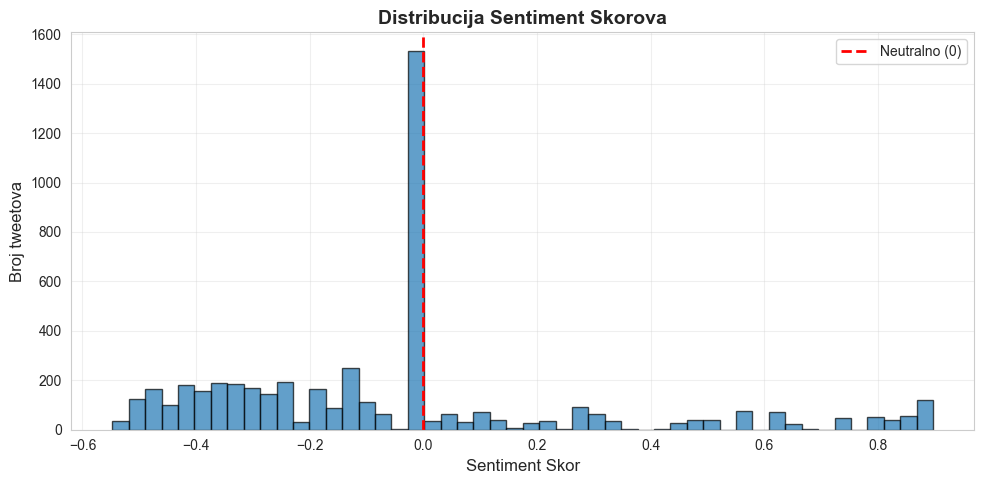

✅ Grafik sačuvan: results/figures/sentiment_score_distribution.png


In [6]:
# Histogram sentiment skorova
plt.figure(figsize=(10, 5))
plt.hist(df['sentiment_score'], bins=50, edgecolor='black', alpha=0.7)
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Neutralno (0)')
plt.xlabel('Sentiment Skor', fontsize=12)
plt.ylabel('Broj tweetova', fontsize=12)
plt.title('Distribucija Sentiment Skorova', fontweight='bold', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/figures/sentiment_score_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Grafik sačuvan: results/figures/sentiment_score_distribution.png")

## 4. Parsiranje Timestampova i Agregacija Po Danima

In [7]:
# Parse timestamp kolonu
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['date'] = df['timestamp'].dt.date

print(f"📅 Period podataka:")
print(f"   Od: {df['date'].min()}")
print(f"   Do: {df['date'].max()}")
print(f"   Trajanje: {(df['date'].max() - df['date'].min()).days} dana")

📅 Period podataka:
   Od: 2024-01-24
   Do: 2024-05-09
   Trajanje: 106 dana


In [8]:
# Agregacija sentimenta po danima
daily_sentiment = df.groupby('date').agg({
    'sentiment_score': ['mean', 'std', 'count'],
    'sentiment': lambda x: x.value_counts().to_dict()
}).reset_index()

# Pojednostavi kolone
daily_sentiment.columns = ['date', 'sentiment_mean', 'sentiment_std', 'tweet_count', 'sentiment_dist']

print(f"\n✅ Dnevna agregacija: {len(daily_sentiment)} dana")
print(f"\nPrvih 10 dana:")
display(daily_sentiment.head(10))


✅ Dnevna agregacija: 107 dana

Prvih 10 dana:


,date,sentiment_mean,sentiment_std,tweet_count,sentiment_dist
0,2024-01-24,-0.058781,0.328015,30,"{'positive': 17, 'neutral': 9, 'negative': 4}"
1,2024-01-25,0.029733,0.334020,46,"{'positive': 21, 'neutral': 15, 'negative': 10}"
2,2024-01-26,-0.061716,0.338720,47,"{'positive': 18, 'negative': 15, 'neutral': 14}"
3,2024-01-27,-0.054668,0.340871,44,"{'positive': 24, 'negative': 13, 'neutral': 7}"
4,2024-01-28,-0.075620,0.251460,53,"{'neutral': 20, 'positive': 19, 'negative': 14}"
5,2024-01-29,-0.028337,0.293466,42,"{'positive': 22, 'neutral': 13, 'negative': 7}"
6,2024-01-30,-0.047386,0.304065,54,"{'positive': 24, 'neutral': 15, 'negative': 15}"
7,2024-01-31,-0.066500,0.288193,46,"{'negative': 16, 'neutral': 16, 'positive': 14}"
8,2024-02-01,-0.067775,0.335638,39,"{'positive': 13, 'neutral': 13, 'negative': 13}"
9,2024-02-02,-0.056188,0.411213,46,"{'positive': 19, 'negative': 17, 'neutral': 10}"


## 5. Preuzimanje Bitcoin Cena (Yahoo Finance)

In [9]:
# Preuzmi Bitcoin cene
print("Preuzimanje Bitcoin cena sa Yahoo Finance...")

# Datum range
start_date = daily_sentiment['date'].min()
end_date = daily_sentiment['date'].max() + timedelta(days=1)

print(f"Period: {start_date} do {end_date}")

# Preuzmi BTC-USD podatke
btc = yf.download('BTC-USD', start=start_date, end=end_date, progress=False)

print(f"\n✅ Bitcoin cene preuzete: {len(btc)} dana")
print(f"\nPrvih 5 dana:")
display(btc.head())

Preuzimanje Bitcoin cena sa Yahoo Finance...
Period: 2024-01-24 do 2024-05-10

✅ Bitcoin cene preuzete: 107 dana

Prvih 5 dana:


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2024-01-24,40077.074219,40483.785156,39508.796875,39877.593750,22359526178
2024-01-25,39933.808594,40254.480469,39545.664062,40075.550781,18491782013
2024-01-26,41816.871094,42209.386719,39825.691406,39936.816406,25598119893
2024-01-27,42120.054688,42195.632812,41431.281250,41815.625000,11422941934
2024-01-28,42035.593750,42797.175781,41696.910156,42126.125000,16858971687


In [10]:
# Pripremi Bitcoin dataframe
btc_df = btc[['Close', 'Volume']].copy()
btc_df.columns = ['btc_price', 'btc_volume']
btc_df['date'] = btc_df.index.date
btc_df = btc_df.reset_index(drop=True)

# Dodaj price change i returns
btc_df['btc_change'] = btc_df['btc_price'].pct_change()
btc_df['btc_change_abs'] = btc_df['btc_price'].diff()

print("✅ Bitcoin dataframe pripremljen")
print(f"\n📊 Bitcoin statistika:")
print(btc_df.describe())

✅ Bitcoin dataframe pripremljen

📊 Bitcoin statistika:
          btc_price    btc_volume  btc_change  btc_change_abs
count    107.000000  1.070000e+02  106.000000      106.000000
mean   59947.275774  3.473397e+10    0.004758      216.725346
std     9644.782226  1.698914e+10    0.031043     1950.705040
min    39933.808594  1.116925e+10   -0.083434    -5635.820312
25%    51802.919922  2.142552e+10   -0.009731     -563.319336
50%    63512.753906  3.215579e+10    0.003165      201.798828
75%    67693.117188  4.277383e+10    0.020852     1250.051758
max    73083.500000  1.028029e+11    0.096925     6000.898438


## 6. Spajanje Sentiment i Cena Podataka

In [11]:
# Spoji sentiment i Bitcoin cene
merged_df = pd.merge(
    daily_sentiment,
    btc_df,
    on='date',
    how='inner'
)

# Ukloni NaN vrednosti (prvi dan nema price change)
merged_df = merged_df.dropna()

print(f"✅ Spojeno: {len(merged_df)} dana sa i sentiment i price podacima")
print(f"\nPrvih 10 redova:")
display(merged_df.head(10))

# Sačuvaj
merged_df.to_csv('../data/processed/sentiment_price_merged.csv', index=False)
print("\n✅ Sačuvano: data/processed/sentiment_price_merged.csv")

✅ Spojeno: 106 dana sa i sentiment i price podacima

Prvih 10 redova:


,date,sentiment_mean,sentiment_std,tweet_count,sentiment_dist,btc_price,btc_volume,btc_change,btc_change_abs
1,2024-01-25,0.029733,0.334020,46,"{'positive': 21, 'neutral': 15, 'negative': 10}",39933.808594,18491782013,-0.003575,-143.265625
2,2024-01-26,-0.061716,0.338720,47,"{'positive': 18, 'negative': 15, 'neutral': 14}",41816.871094,25598119893,0.047155,1883.062500
3,2024-01-27,-0.054668,0.340871,44,"{'positive': 24, 'negative': 13, 'neutral': 7}",42120.054688,11422941934,0.007250,303.183594
4,2024-01-28,-0.075620,0.251460,53,"{'neutral': 20, 'positive': 19, 'negative': 14}",42035.593750,16858971687,-0.002005,-84.460938
5,2024-01-29,-0.028337,0.293466,42,"{'positive': 22, 'neutral': 13, 'negative': 7}",43288.246094,20668476578,0.029800,1252.652344
6,2024-01-30,-0.047386,0.304065,54,"{'positive': 24, 'neutral': 15, 'negative': 15}",42952.609375,23842814518,-0.007754,-335.636719
7,2024-01-31,-0.066500,0.288193,46,"{'negative': 16, 'neutral': 16, 'positive': 14}",42582.605469,24673628793,-0.008614,-370.003906
8,2024-02-01,-0.067775,0.335638,39,"{'positive': 13, 'neutral': 13, 'negative': 13}",43075.773438,21423953779,0.011581,493.167969
9,2024-02-02,-0.056188,0.411213,46,"{'positive': 19, 'negative': 17, 'neutral': 10}",43185.859375,18603843039,0.002556,110.085938
10,2024-02-03,0.000885,0.357536,45,"{'positive': 22, 'neutral': 12, 'negative': 11}",42992.250000,11169245236,-0.004483,-193.609375



✅ Sačuvano: data/processed/sentiment_price_merged.csv


## 7. Visualizacija: Sentiment vs Cena Kroz Vreme

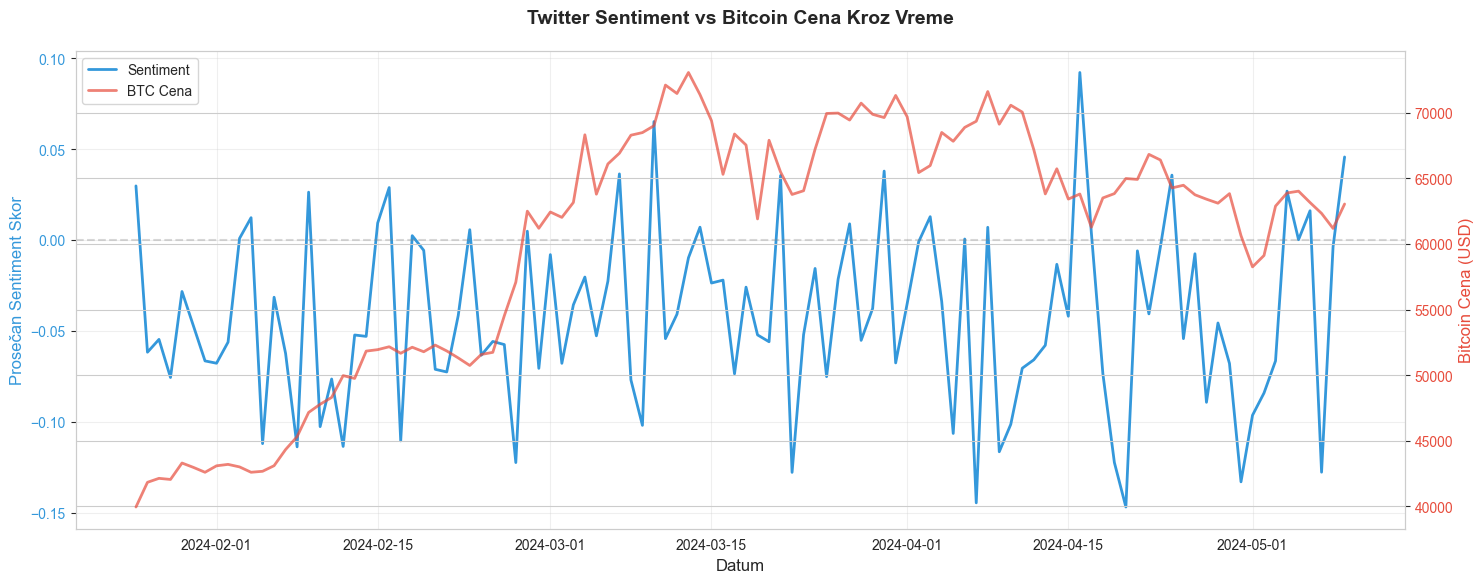

✅ Grafik sačuvan: results/figures/sentiment_vs_price_timeline.png


In [12]:
# Dual-axis plot: Sentiment i Cena
fig, ax1 = plt.subplots(figsize=(15, 6))

# Sentiment (leva osa)
color = '#3498db'
ax1.set_xlabel('Datum', fontsize=12)
ax1.set_ylabel('Prosečan Sentiment Skor', color=color, fontsize=12)
ax1.plot(merged_df['date'], merged_df['sentiment_mean'], 
         color=color, linewidth=2, label='Sentiment')
ax1.tick_params(axis='y', labelcolor=color)
ax1.axhline(0, color='gray', linestyle='--', alpha=0.3)
ax1.grid(alpha=0.3)

# Bitcoin cena (desna osa)
ax2 = ax1.twinx()
color = '#e74c3c'
ax2.set_ylabel('Bitcoin Cena (USD)', color=color, fontsize=12)
ax2.plot(merged_df['date'], merged_df['btc_price'], 
         color=color, linewidth=2, label='BTC Cena', alpha=0.7)
ax2.tick_params(axis='y', labelcolor=color)

# Naslov i legenda
plt.title('Twitter Sentiment vs Bitcoin Cena Kroz Vreme', 
          fontsize=14, fontweight='bold', pad=20)
fig.tight_layout()

# Legenda
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.savefig('../results/figures/sentiment_vs_price_timeline.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Grafik sačuvan: results/figures/sentiment_vs_price_timeline.png")

## 8. Korelaciona Analiza

In [13]:
# Pearson korelacija (linearna)
pearson_corr_price, pearson_p_price = pearsonr(
    merged_df['sentiment_mean'], 
    merged_df['btc_price']
)

# Pearson korelacija sa price change
pearson_corr_change, pearson_p_change = pearsonr(
    merged_df['sentiment_mean'], 
    merged_df['btc_change']
)

# Spearman korelacija (monotona)
spearman_corr_price, spearman_p_price = spearmanr(
    merged_df['sentiment_mean'], 
    merged_df['btc_price']
)

spearman_corr_change, spearman_p_change = spearmanr(
    merged_df['sentiment_mean'], 
    merged_df['btc_change']
)

print("="*70)
print("KORELACIONA ANALIZA")
print("="*70)

print("\n📊 SENTIMENT vs BITCOIN CENA:")
print(f"   Pearson korelacija:  {pearson_corr_price:.4f} (p={pearson_p_price:.4f})")
print(f"   Spearman korelacija: {spearman_corr_price:.4f} (p={spearman_p_price:.4f})")

print("\n📊 SENTIMENT vs BITCOIN PRICE CHANGE:")
print(f"   Pearson korelacija:  {pearson_corr_change:.4f} (p={pearson_p_change:.4f})")
print(f"   Spearman korelacija: {spearman_corr_change:.4f} (p={spearman_p_change:.4f})")

print("\n💡 INTERPRETACIJA:")
if abs(pearson_corr_price) < 0.3:
    print("   Slaba korelacija između sentimenta i cene")
elif abs(pearson_corr_price) < 0.7:
    print("   Umerena korelacija između sentimenta i cene")
else:
    print("   Jaka korelacija između sentimenta i cene")

if pearson_p_price < 0.05:
    print(f"   ✅ Statistički značajno (p < 0.05)")
else:
    print(f"   ⚠️  NIJE statistički značajno (p >= 0.05)")

print("="*70)

KORELACIONA ANALIZA

📊 SENTIMENT vs BITCOIN CENA:
   Pearson korelacija:  0.0942 (p=0.3367)
   Spearman korelacija: 0.1215 (p=0.2149)

📊 SENTIMENT vs BITCOIN PRICE CHANGE:
   Pearson korelacija:  -0.0097 (p=0.9213)
   Spearman korelacija: -0.0617 (p=0.5299)

💡 INTERPRETACIJA:
   Slaba korelacija između sentimenta i cene
   ⚠️  NIJE statistički značajno (p >= 0.05)


### Scatter Plot: Sentiment vs Cena

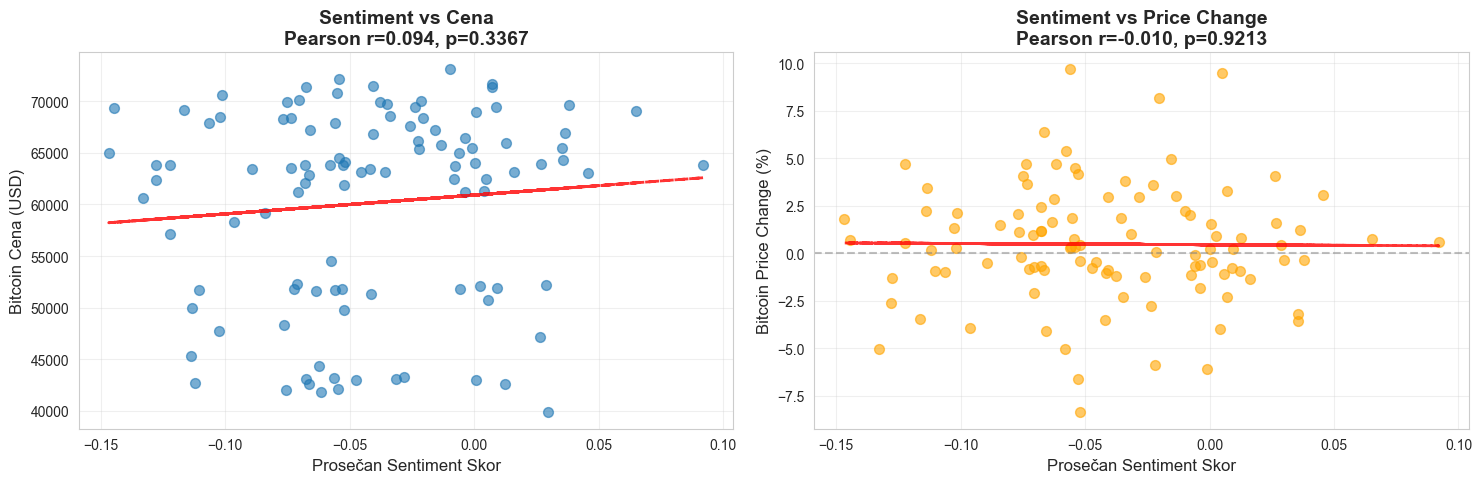

✅ Grafik sačuvan: results/figures/sentiment_price_correlation.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Sentiment vs Price
axes[0].scatter(merged_df['sentiment_mean'], merged_df['btc_price'], 
                alpha=0.6, s=50)
axes[0].set_xlabel('Prosečan Sentiment Skor', fontsize=12)
axes[0].set_ylabel('Bitcoin Cena (USD)', fontsize=12)
axes[0].set_title(f'Sentiment vs Cena\nPearson r={pearson_corr_price:.3f}, p={pearson_p_price:.4f}',
                  fontweight='bold')
axes[0].grid(alpha=0.3)

# Regression line
z = np.polyfit(merged_df['sentiment_mean'], merged_df['btc_price'], 1)
p = np.poly1d(z)
axes[0].plot(merged_df['sentiment_mean'], p(merged_df['sentiment_mean']), 
             "r--", alpha=0.8, linewidth=2)

# Sentiment vs Price Change
axes[1].scatter(merged_df['sentiment_mean'], merged_df['btc_change']*100, 
                alpha=0.6, s=50, color='orange')
axes[1].set_xlabel('Prosečan Sentiment Skor', fontsize=12)
axes[1].set_ylabel('Bitcoin Price Change (%)', fontsize=12)
axes[1].set_title(f'Sentiment vs Price Change\nPearson r={pearson_corr_change:.3f}, p={pearson_p_change:.4f}',
                  fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)

# Regression line
z2 = np.polyfit(merged_df['sentiment_mean'], merged_df['btc_change']*100, 1)
p2 = np.poly1d(z2)
axes[1].plot(merged_df['sentiment_mean'], p2(merged_df['sentiment_mean']), 
             "r--", alpha=0.8, linewidth=2)

plt.tight_layout()
plt.savefig('../results/figures/sentiment_price_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Grafik sačuvan: results/figures/sentiment_price_correlation.png")

## 9. Lag Analysis - Vodeći/Zaostali Indikatori

In [15]:
# Testiraj različite lagove (-7 do +7 dana)
lags = range(-7, 8)
correlations = []
p_values = []

for lag in lags:
    if lag < 0:
        # Sentiment vodi (prediktor)
        sentiment = merged_df['sentiment_mean'].iloc[:lag]
        price_change = merged_df['btc_change'].iloc[-lag:]
    elif lag > 0:
        # Cena vodi (sentiment reaguje)
        sentiment = merged_df['sentiment_mean'].iloc[lag:]
        price_change = merged_df['btc_change'].iloc[:-lag]
    else:
        # Bez laga
        sentiment = merged_df['sentiment_mean']
        price_change = merged_df['btc_change']
    
    if len(sentiment) > 0 and len(price_change) > 0:
        corr, p_val = pearsonr(sentiment, price_change)
        correlations.append(corr)
        p_values.append(p_val)
    else:
        correlations.append(np.nan)
        p_values.append(np.nan)

# Kreir aj dataframe
lag_df = pd.DataFrame({
    'lag': lags,
    'correlation': correlations,
    'p_value': p_values
})

print("\n📊 LAG ANALYSIS REZULTATI:")
print("="*70)
print("Negativan lag: Sentiment VODI cenu (prediktor)")
print("Pozitivan lag: Cena VODI sentiment (reakcija)")
print("="*70)
print(lag_df)

# Pronađi najjaču korelaciju
best_lag_idx = lag_df['correlation'].abs().idxmax()
best_lag = lag_df.loc[best_lag_idx, 'lag']
best_corr = lag_df.loc[best_lag_idx, 'correlation']
best_p = lag_df.loc[best_lag_idx, 'p_value']

print(f"\n💡 NAJJAČA KORELACIJA:")
print(f"   Lag: {best_lag} dana")
print(f"   Korelacija: {best_corr:.4f}")
print(f"   P-value: {best_p:.4f}")

if best_lag < 0:
    print(f"   → Sentiment vodi cenu za {abs(best_lag)} dana (prediktor)")
elif best_lag > 0:
    print(f"   → Cena vodi sentiment za {best_lag} dana (reakcija)")
else:
    print(f"   → Simultana veza (isti dan)")


📊 LAG ANALYSIS REZULTATI:
Negativan lag: Sentiment VODI cenu (prediktor)
Pozitivan lag: Cena VODI sentiment (reakcija)
    lag  correlation   p_value
0    -7     0.044183  0.664114
1    -6    -0.117170  0.245652
2    -5     0.132165  0.187674
3    -4     0.060220  0.547677
4    -3    -0.085030  0.393116
5    -2    -0.071174  0.472771
6    -1    -0.111663  0.256771
7     0    -0.009706  0.921337
8     1    -0.021312  0.829149
9     2    -0.016798  0.865604
10    3     0.069484  0.485539
11    4     0.031731  0.751550
12    5    -0.149996  0.134351
13    6     0.226207  0.023633
14    7     0.111591  0.271483

💡 NAJJAČA KORELACIJA:
   Lag: 6 dana
   Korelacija: 0.2262
   P-value: 0.0236
   → Cena vodi sentiment za 6 dana (reakcija)


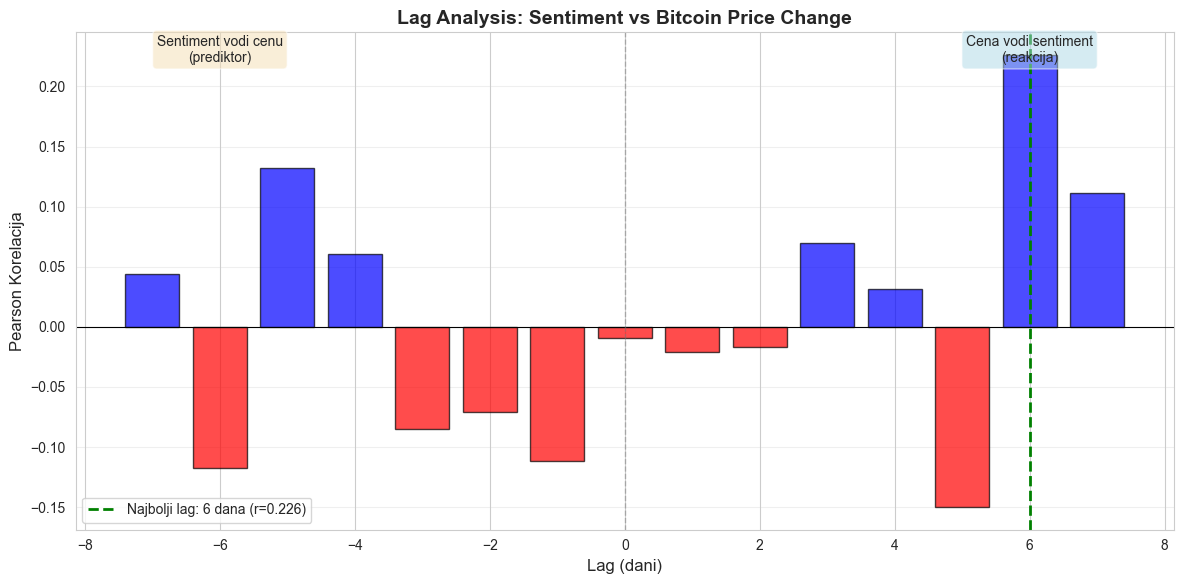

✅ Grafik sačuvan: results/figures/lag_analysis.png


In [16]:
# Plot lag analysis
fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(lag_df['lag'], lag_df['correlation'], 
       color=['red' if x < 0 else 'blue' for x in lag_df['correlation']],
       alpha=0.7, edgecolor='black')

ax.axhline(0, color='black', linestyle='-', linewidth=0.8)
ax.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

ax.set_xlabel('Lag (dani)', fontsize=12)
ax.set_ylabel('Pearson Korelacija', fontsize=12)
ax.set_title('Lag Analysis: Sentiment vs Bitcoin Price Change', 
             fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Označi najbolji lag
ax.axvline(best_lag, color='green', linestyle='--', linewidth=2, 
           label=f'Najbolji lag: {best_lag} dana (r={best_corr:.3f})')
ax.legend(fontsize=10)

# Anotacije
ax.text(-6, ax.get_ylim()[1]*0.9, 'Sentiment vodi cenu\n(prediktor)', 
        fontsize=10, ha='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.text(6, ax.get_ylim()[1]*0.9, 'Cena vodi sentiment\n(reakcija)', 
        fontsize=10, ha='center', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.savefig('../results/figures/lag_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Grafik sačuvan: results/figures/lag_analysis.png")

## 10. Moving Averages - Glatke Linije

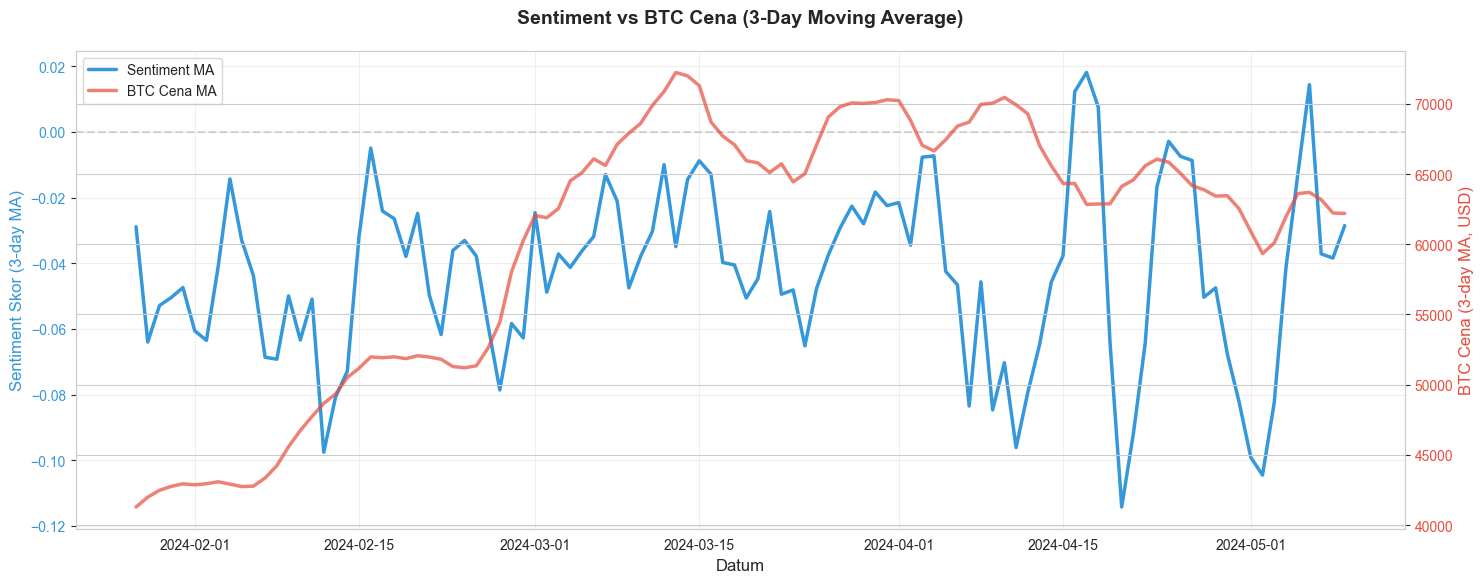

✅ Grafik sačuvan: results/figures/sentiment_price_ma.png


In [17]:
# Dodaj moving averages
window = 3  # 3-day MA

merged_df['sentiment_ma'] = merged_df['sentiment_mean'].rolling(window=window).mean()
merged_df['btc_price_ma'] = merged_df['btc_price'].rolling(window=window).mean()

# Plot sa MA
fig, ax1 = plt.subplots(figsize=(15, 6))

# Sentiment
color = '#3498db'
ax1.set_xlabel('Datum', fontsize=12)
ax1.set_ylabel('Sentiment Skor (3-day MA)', color=color, fontsize=12)
ax1.plot(merged_df['date'], merged_df['sentiment_ma'], 
         color=color, linewidth=2.5, label='Sentiment MA')
ax1.tick_params(axis='y', labelcolor=color)
ax1.axhline(0, color='gray', linestyle='--', alpha=0.3)
ax1.grid(alpha=0.3)

# Bitcoin cena
ax2 = ax1.twinx()
color = '#e74c3c'
ax2.set_ylabel('BTC Cena (3-day MA, USD)', color=color, fontsize=12)
ax2.plot(merged_df['date'], merged_df['btc_price_ma'], 
         color=color, linewidth=2.5, label='BTC Cena MA', alpha=0.7)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Sentiment vs BTC Cena (3-Day Moving Average)', 
          fontsize=14, fontweight='bold', pad=20)
fig.tight_layout()

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.savefig('../results/figures/sentiment_price_ma.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Grafik sačuvan: results/figures/sentiment_price_ma.png")

## 11. Sačuvaj Rezultate

In [18]:
import json

# Kreiraj dictionary sa rezultatima
correlation_results = {
    'analysis_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'data_period': {
        'start': str(merged_df['date'].min()),
        'end': str(merged_df['date'].max()),
        'num_days': len(merged_df)
    },
    'sentiment_stats': {
        'mean': float(merged_df['sentiment_mean'].mean()),
        'std': float(merged_df['sentiment_mean'].std()),
        'min': float(merged_df['sentiment_mean'].min()),
        'max': float(merged_df['sentiment_mean'].max())
    },
    'correlations': {
        'sentiment_vs_price': {
            'pearson': {'r': float(pearson_corr_price), 'p': float(pearson_p_price)},
            'spearman': {'r': float(spearman_corr_price), 'p': float(spearman_p_price)}
        },
        'sentiment_vs_price_change': {
            'pearson': {'r': float(pearson_corr_change), 'p': float(pearson_p_change)},
            'spearman': {'r': float(spearman_corr_change), 'p': float(spearman_p_change)}
        }
    },
    'lag_analysis': {
        'best_lag_days': int(best_lag),
        'best_correlation': float(best_corr),
        'best_p_value': float(best_p),
        'interpretation': 'sentiment leads' if best_lag < 0 else 'price leads' if best_lag > 0 else 'simultaneous'
    }
}

# Sačuvaj u JSON
with open('../results/correlation_analysis_results.json', 'w') as f:
    json.dump(correlation_results, f, indent=2)

print("✅ Rezultati sačuvani: results/correlation_analysis_results.json")

✅ Rezultati sačuvani: results/correlation_analysis_results.json


## 12. Finalni Sažetak i Zaključci

In [19]:
print("\n" + "="*80)
print("FINALNI REZULTATI - KORELACIONA ANALIZA")
print("="*80)

print(f"\n📅 PERIOD ANALIZE:")
print(f"   Od: {merged_df['date'].min()}")
print(f"   Do: {merged_df['date'].max()}")
print(f"   Broj dana: {len(merged_df)}")
print(f"   Broj tweetova: {len(df):,}")

print(f"\n📊 SENTIMENT STATISTIKA:")
print(f"   Prosečan skor: {merged_df['sentiment_mean'].mean():.4f}")
print(f"   Std dev: {merged_df['sentiment_mean'].std():.4f}")
print(f"   Raspon: [{merged_df['sentiment_mean'].min():.4f}, {merged_df['sentiment_mean'].max():.4f}]")

print(f"\n💰 BITCOIN STATISTIKA:")
print(f"   Prosečna cena: ${merged_df['btc_price'].mean():,.2f}")
print(f"   Min cena: ${merged_df['btc_price'].min():,.2f}")
print(f"   Max cena: ${merged_df['btc_price'].max():,.2f}")
print(f"   Prosečna dnevna promena: {merged_df['btc_change'].mean()*100:.2f}%")

print(f"\n🔗 KORELACIJE:")
print(f"   Sentiment vs Cena:")
print(f"      Pearson: {pearson_corr_price:.4f} (p={pearson_p_price:.4f})")
print(f"      Spearman: {spearman_corr_price:.4f} (p={spearman_p_price:.4f})")
print(f"\n   Sentiment vs Price Change:")
print(f"      Pearson: {pearson_corr_change:.4f} (p={pearson_p_change:.4f})")
print(f"      Spearman: {spearman_corr_change:.4f} (p={spearman_p_change:.4f})")

print(f"\n⏱️  LAG ANALYSIS:")
print(f"   Najbolji lag: {best_lag} dana")
print(f"   Korelacija: {best_corr:.4f} (p={best_p:.4f})")
if best_lag < 0:
    print(f"   → Twitter sentiment PREDVIĐA Bitcoin cenu za {abs(best_lag)} dana")
elif best_lag > 0:
    print(f"   → Bitcoin cena UTIČE na sentiment za {best_lag} dana")
else:
    print(f"   → Simultana veza (isti dan)")

print(f"\n💾 SAČUVANI FAJLOVI:")
print(f"   - data/processed/sentiment_price_merged.csv")
print(f"   - results/correlation_analysis_results.json")
print(f"   - results/figures/sentiment_score_distribution.png")
print(f"   - results/figures/sentiment_vs_price_timeline.png")
print(f"   - results/figures/sentiment_price_correlation.png")
print(f"   - results/figures/lag_analysis.png")
print(f"   - results/figures/sentiment_price_ma.png")

print("\n" + "="*80)
print("✅ NOTEBOOK 05 ZAVRŠEN!")
print("="*80)

print("\n💡 ZAKLJUČCI ZA DIPLOMSKI RAD:")
print("\n1. Korelacija sentiment-cena:")
if abs(pearson_corr_price) < 0.3:
    print("   - Slaba korelacija detektovana")
elif abs(pearson_corr_price) < 0.7:
    print("   - Umerena korelacija detektovana")
else:
    print("   - Jaka korelacija detektovana")

if pearson_p_price < 0.05:
    print("   - Statistički značajna veza (p < 0.05)")
else:
    print("   - NIJE statistički značajna (p >= 0.05)")

print("\n2. Prediktivna moć:")
if best_lag < 0:
    print(f"   - Twitter sentiment može biti vodeći indikator")
    print(f"   - Promena sentimenta {abs(best_lag)} dana pre price promene")
else:
    print(f"   - Twitter sentiment više reaguje na cenu")
    print(f"   - Nema jakih dokaza za prediktivnu moć")

print("\n3. Praktična primena:")
print("   - Sentiment analiza može biti deo trading strategije")
print("   - Kombinovati sa drugim tehničkim indikatorima")
print("   - Paziti na ograničenja (mali dataset, kratki period)")

print("\n🎓 SVE SPREMNO ZA DIPLOMSKI RAD!\n")


FINALNI REZULTATI - KORELACIONA ANALIZA

📅 PERIOD ANALIZE:
   Od: 2024-01-25
   Do: 2024-05-09
   Broj dana: 106
   Broj tweetova: 5,000

📊 SENTIMENT STATISTIKA:
   Prosečan skor: -0.0420
   Std dev: 0.0490
   Raspon: [-0.1468, 0.0921]

💰 BITCOIN STATISTIKA:
   Prosečna cena: $60,134.73
   Min cena: $39,933.81
   Max cena: $73,083.50
   Prosečna dnevna promena: 0.48%

🔗 KORELACIJE:
   Sentiment vs Cena:
      Pearson: 0.0942 (p=0.3367)
      Spearman: 0.1215 (p=0.2149)

   Sentiment vs Price Change:
      Pearson: -0.0097 (p=0.9213)
      Spearman: -0.0617 (p=0.5299)

⏱️  LAG ANALYSIS:
   Najbolji lag: 6 dana
   Korelacija: 0.2262 (p=0.0236)
   → Bitcoin cena UTIČE na sentiment za 6 dana

💾 SAČUVANI FAJLOVI:
   - data/processed/sentiment_price_merged.csv
   - results/correlation_analysis_results.json
   - results/figures/sentiment_score_distribution.png
   - results/figures/sentiment_vs_price_timeline.png
   - results/figures/sentiment_price_correlation.png
   - results/figures/lag_an